"""
Malaria Cell Detection using Transfer Learning with ResNet50
==============================================================
A comprehensive implementation comparing frozen vs fine-tuned transfer learning approaches.

Author: Isaac MUGISHA
Date: October 2025
"""

In [4]:
# ============================================================================
# SECTION 1: IMPORTS AND ENVIRONMENT SETUP
# ============================================================================

import os
import random
import shutil
import itertools
from pathlib import Path

# Data Science & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("✓ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")


✓ All libraries imported successfully
TensorFlow version: 2.19.0


In [5]:
# ============================================================================
# SECTION 2: DATA DOWNLOAD AND PREPARATION
# ============================================================================

def setup_google_drive():
    """Mount Google Drive for Colab environment."""
    try:
        from google.colab import drive
        drive.mount('/content/drive/')
        print("✓ Google Drive mounted successfully")
        return True
    except ImportError:
        print("ℹ Not running in Colab environment")
        return False


def download_malaria_dataset(save_in_drive=False, drive_path=None):
    """
    Download and extract the malaria cell images dataset.

    Args:
        save_in_drive: If True, save to Google Drive
        drive_path: Path to save in Drive (if save_in_drive=True)
    """
    url = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"

    if save_in_drive and drive_path:
        download_cmd = f'wget {url} -P "{drive_path}"'
        unzip_cmd = f'unzip "{drive_path}/cell_images.zip" -d "{drive_path}/"'
    else:
        # Clean previous downloads
        os.system('rm -rf cell_images.*')
        download_cmd = f'wget {url}'
        unzip_cmd = 'unzip cell_images.zip >/dev/null 2>&1'

    print("⬇ Downloading dataset...")
    os.system(download_cmd)

    print("📦 Extracting dataset...")
    os.system(unzip_cmd)

    print("✓ Dataset downloaded and extracted")


def create_train_test_split(source_dir='cell_images', train_ratio=0.8):
    """
    Split dataset into training and testing sets with proper directory structure.

    Args:
        source_dir: Source directory containing cell_images
        train_ratio: Ratio of data for training (default: 0.8)

    Returns:
        Dictionary with split statistics
    """
    classes = ['Parasitized', 'Uninfected']

    # Create directory structure
    for split in ['train', 'test']:
        for class_name in classes:
            os.makedirs(f'{split}/{class_name}', exist_ok=True)

    print("✓ Created train/test directory structure")

    stats = {}

    for class_name in classes:
        class_path = os.path.join(source_dir, class_name)

        # Get all image files
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Split files
        train_files, test_files = train_test_split(
            image_files, train_size=train_ratio, random_state=42
        )

        # Copy to respective directories
        for file in train_files:
            shutil.copy2(
                os.path.join(class_path, file),
                os.path.join('train', class_name, file)
            )

        for file in test_files:
            shutil.copy2(
                os.path.join(class_path, file),
                os.path.join('test', class_name, file)
            )

        stats[class_name] = {
            'total': len(image_files),
            'train': len(train_files),
            'test': len(test_files)
        }

        print(f"\n{class_name}:")
        print(f"  Total: {len(image_files)} images")
        print(f"  Train: {len(train_files)} images")
        print(f"  Test: {len(test_files)} images")

    print("\n✓ Data splitting completed")
    return stats

In [6]:
# ============================================================================
# SECTION 3: DATA PIPELINE CONFIGURATION
# ============================================================================

class DataConfig:
    """Configuration parameters for data pipeline."""
    IMG_SIZE = (224, 224)  # ResNet50 input size
    BATCH_SIZE = 64
    AUTOTUNE = tf.data.AUTOTUNE
    TRAIN_PATH = 'train'
    TEST_PATH = 'test'


def preprocess_for_resnet(image):
    """
    Preprocess images for ResNet50 input.

    Args:
        image: Input image tensor

    Returns:
        Preprocessed image tensor
    """
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    image = tf.image.resize(image, DataConfig.IMG_SIZE)
    return image


def create_optimized_datasets(train_dir, val_dir, config=DataConfig):
    """
    Create optimized TensorFlow data pipelines.

    Args:
        train_dir: Training data directory
        val_dir: Validation data directory
        config: Configuration object

    Returns:
        Tuple of (train_dataset, validation_dataset, class_names)
    """
    # Load datasets from directories
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=config.IMG_SIZE,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        seed=42
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=config.IMG_SIZE,
        batch_size=config.BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names

    # Optimize with preprocessing and prefetching
    train_ds = (train_ds
                .map(lambda x, y: (preprocess_for_resnet(x), y),
                     num_parallel_calls=config.AUTOTUNE)
                .prefetch(config.AUTOTUNE))

    val_ds = (val_ds
              .map(lambda x, y: (preprocess_for_resnet(x), y),
                   num_parallel_calls=config.AUTOTUNE)
              .prefetch(config.AUTOTUNE))

    print("✓ Optimized data pipelines created")
    print(f"  Classes: {class_names}")

    return train_ds, val_ds, class_names


def create_data_augmentation():
    """
    Create data augmentation pipeline.

    Returns:
        Sequential model with augmentation layers
    """
    augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.06),
        layers.RandomZoom(0.06),
        layers.RandomTranslation(0.05, 0.05),
    ], name="data_augmentation")

    return augmentation


In [7]:
# ============================================================================
# SECTION 4: MODEL ARCHITECTURE
# ============================================================================

def build_resnet_transfer_model(img_size=DataConfig.IMG_SIZE,
                                 dropout_rate=0.5,
                                 dense_units=256):
    """
    Build ResNet50-based transfer learning model.

    Architecture:
        - Pre-trained ResNet50 base (frozen initially)
        - Data augmentation layer
        - Global Average Pooling
        - Batch Normalization
        - Dense layer with dropout
        - Binary classification output

    Args:
        img_size: Input image dimensions
        dropout_rate: Dropout rate for regularization
        dense_units: Units in dense classification layer

    Returns:
        Tuple of (complete_model, base_model)
    """
    # Load pre-trained ResNet50
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=img_size + (3,)
    )
    base_model.trainable = False  # Freeze base initially

    # Build classification head
    inputs = layers.Input(shape=img_size + (3,), name='input_layer')

    # Data augmentation (only active during training)
    augmentation = create_data_augmentation()
    x = augmentation(inputs)

    # Feature extraction with frozen base
    x = base_model(x, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dense(dense_units, activation='relu', name='dense_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    # Create model
    model = Model(inputs, outputs, name='resnet50_malaria_detector')

    return model, base_model


def print_model_summary(model, base_model):
    """
    Print detailed model summary with parameter counts.

    Args:
        model: Complete model
        base_model: Base ResNet50 model
    """
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w)
                           for w in model.trainable_weights])
    frozen_params = total_params - trainable_params

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE SUMMARY")
    print("="*60)
    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters:    {frozen_params:,}")
    print(f"Base model layers:    {len(base_model.layers)}")
    print("="*60 + "\n")


In [8]:
# ============================================================================
# SECTION 5: TRAINING UTILITIES
# ============================================================================

def create_callbacks(patience=3, lr_patience=2):
    """
    Create training callbacks for optimization.

    Args:
        patience: Epochs to wait for EarlyStopping
        lr_patience: Epochs to wait for ReduceLROnPlateau

    Returns:
        List of Keras callbacks
    """
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=lr_patience,
        min_lr=1e-7,
        verbose=1,
        mode='min'
    )

    return [early_stopping, reduce_lr]


def compile_model(model, learning_rate=1e-4):
    """
    Compile model with optimizer and metrics.

    Args:
        model: Keras model to compile
        learning_rate: Learning rate for optimizer
    """
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    print(f"✓ Model compiled with learning rate: {learning_rate}")


def train_model(model, train_ds, val_ds, epochs, callbacks):
    """
    Train the model.

    Args:
        model: Compiled model
        train_ds: Training dataset
        val_ds: Validation dataset
        epochs: Number of training epochs
        callbacks: List of Keras callbacks

    Returns:
        Training history object
    """
    print(f"\n{'='*60}")
    print(f"STARTING TRAINING - {epochs} EPOCHS")
    print(f"{'='*60}\n")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    print(f"\n{'='*60}")
    print("TRAINING COMPLETED")
    print(f"{'='*60}\n")

    return history


def unfreeze_top_layers(base_model, n_layers=30, freeze_bn=True):
    """
    Unfreeze top N layers of the base model for fine-tuning.

    Args:
        base_model: Base model to unfreeze
        n_layers: Number of top layers to unfreeze
        freeze_bn: If True, keep BatchNormalization layers frozen

    Returns:
        Dictionary with layer statistics
    """
    base_model.trainable = True

    frozen_count = 0
    unfrozen_count = 0

    for i, layer in enumerate(base_model.layers):
        if i < len(base_model.layers) - n_layers:
            layer.trainable = False
            frozen_count += 1
        else:
            # Keep BatchNorm frozen for stability during fine-tuning
            if freeze_bn and isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
                frozen_count += 1
            else:
                layer.trainable = True
                unfrozen_count += 1

    stats = {
        'frozen': frozen_count,
        'unfrozen': unfrozen_count,
        'total': len(base_model.layers)
    }

    print(f"\n{'='*60}")
    print(f"FINE-TUNING CONFIGURATION")
    print(f"{'='*60}")
    print(f"Frozen layers:   {frozen_count}")
    print(f"Unfrozen layers: {unfrozen_count}")
    print(f"Total layers:    {len(base_model.layers)}")
    print(f"{'='*60}\n")

    return stats

In [9]:
# ============================================================================
# SECTION 6: EVALUATION UTILITIES
# ============================================================================

def evaluate_model(model, dataset, class_names):
    """
    Comprehensive model evaluation.

    Args:
        model: Trained model
        dataset: Dataset for evaluation
        class_names: List of class names

    Returns:
        Dictionary containing:
        - metrics: Dict of performance metrics
        - y_true: True labels
        - y_pred: Predicted labels
        - y_prob: Prediction probabilities
    """
    y_true = []
    y_prob = []

    print("🔍 Evaluating model...")

    # Collect predictions
    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0).ravel()
        y_prob.extend(probs)
        y_true.extend(y_batch.numpy())

    # Convert to arrays
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob),
    }

    # Calculate specificity
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0

    print("✓ Evaluation complete\n")

    return {
        'metrics': metrics,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob
    }


def print_metrics(metrics, title="Model Performance"):
    """
    Print evaluation metrics in a formatted table.

    Args:
        metrics: Dictionary of metrics
        title: Title for the metrics display
    """
    print(f"\n{'='*60}")
    print(f"{title.upper()}")
    print(f"{'='*60}")

    for metric_name, value in metrics.items():
        print(f"{metric_name.upper():<15}: {value:.4f} ({value*100:.2f}%)")

    print(f"{'='*60}\n")


In [10]:
# ============================================================================
# SECTION 7: VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_history(history, title='Training History', save_path=None):
    """
    Plot comprehensive training history with multiple metrics.

    Args:
        history: Keras training history
        title: Plot title
        save_path: Optional path to save figure
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Extract history data
    epochs_range = range(1, len(history.history['loss']) + 1)

    # Plot 1: Accuracy
    axes[0, 0].plot(epochs_range, history.history['accuracy'],
                    'b-o', label='Training', linewidth=2, markersize=6)
    axes[0, 0].plot(epochs_range, history.history['val_accuracy'],
                    'r-s', label='Validation', linewidth=2, markersize=6)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Loss
    axes[0, 1].plot(epochs_range, history.history['loss'],
                    'b-o', label='Training', linewidth=2, markersize=6)
    axes[0, 1].plot(epochs_range, history.history['val_loss'],
                    'r-s', label='Validation', linewidth=2, markersize=6)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: AUC
    axes[1, 0].plot(epochs_range, history.history['auc'],
                    'b-o', label='Training', linewidth=2, markersize=6)
    axes[1, 0].plot(epochs_range, history.history['val_auc'],
                    'r-s', label='Validation', linewidth=2, markersize=6)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('AUC Score', fontsize=12)
    axes[1, 0].set_title('Area Under ROC Curve', fontsize=14, fontweight='bold')
    axes[1, 0].legend(fontsize=11)
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Learning Rate (if available)
    if 'lr' in history.history:
        axes[1, 1].plot(epochs_range, history.history['lr'],
                       'g-o', linewidth=2, markersize=6)
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
        axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        # Plot precision and recall if lr not available
        if 'precision' in history.history:
            axes[1, 1].plot(epochs_range, history.history['precision'],
                           'g-o', label='Training Precision', linewidth=2, markersize=6)
            axes[1, 1].plot(epochs_range, history.history['val_precision'],
                           'c-s', label='Val Precision', linewidth=2, markersize=6)
            axes[1, 1].set_xlabel('Epoch', fontsize=12)
            axes[1, 1].set_ylabel('Score', fontsize=12)
            axes[1, 1].set_title('Precision', fontsize=14, fontweight='bold')
            axes[1, 1].legend(fontsize=11)
            axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Training history saved to {save_path}")

    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names,
                         title='Confusion Matrix', save_path=None):
    """
    Plot detailed confusion matrix with percentages.

    Args:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class names
        title: Plot title
        save_path: Optional path to save figure
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    # Set ticks and labels
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           xlabel='Predicted Label',
           ylabel='True Label',
           title=title)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add text annotations with counts and percentages
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            percentage = cm_normalized[i, j] * 100
            text = f'{count}\n({percentage:.1f}%)'
            ax.text(j, i, text,
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=14, fontweight='bold')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Confusion matrix saved to {save_path}")

    plt.show()

    # Print additional statistics
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix Statistics:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")


def plot_roc_curve(y_true, y_prob, title='ROC Curve', save_path=None):
    """
    Plot ROC curve with AUC score and optimal threshold.

    Args:
        y_true: True labels
        y_prob: Prediction probabilities
        title: Plot title
        save_path: Optional path to save figure
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    # Find optimal threshold (Youden's index)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    plt.figure(figsize=(10, 8))

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=3, label=f'ROC Curve (AUC = {auc_score:.4f})')

    # Plot diagonal reference line
    plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=2,
             label='Random Classifier (AUC = 0.5000)')

    # Mark optimal threshold
    plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=12,
             label=f'Optimal Threshold = {optimal_threshold:.3f}')

    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ ROC curve saved to {save_path}")

    plt.show()

    print(f"\nROC Curve Analysis:")
    print(f"  AUC Score: {auc_score:.4f}")
    print(f"  Optimal Threshold: {optimal_threshold:.3f}")
    print(f"  Sensitivity at optimal: {tpr[optimal_idx]:.4f}")
    print(f"  Specificity at optimal: {1-fpr[optimal_idx]:.4f}")


def plot_precision_recall_curve(y_true, y_prob, title='Precision-Recall Curve',
                                save_path=None):
    """
    Plot Precision-Recall curve.

    Args:
        y_true: True labels
        y_prob: Prediction probabilities
        title: Plot title
        save_path: Optional path to save figure
    """
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    ap_score = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(10, 8))

    plt.plot(recall, precision, linewidth=3,
             label=f'PR Curve (AP = {ap_score:.4f})')

    # Baseline
    baseline = np.sum(y_true) / len(y_true)
    plt.axhline(y=baseline, color='gray', linestyle='--', linewidth=2,
                label=f'Baseline (AP = {baseline:.4f})')

    plt.xlabel('Recall (Sensitivity)', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='lower left')
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Precision-Recall curve saved to {save_path}")

    plt.show()

    print(f"\nPrecision-Recall Analysis:")
    print(f"  Average Precision: {ap_score:.4f}")


def plot_sample_predictions(model, dataset, class_names, n_samples=12,
                           save_path=None):
    """
    Visualize sample predictions with confidence scores.

    Args:
        model: Trained model
        dataset: Dataset to sample from
        class_names: List of class names
        n_samples: Number of samples to display
        save_path: Optional path to save figure
    """
    # Get a batch of images
    for images, labels in dataset.take(1):
        predictions = model.predict(images[:n_samples], verbose=0).ravel()

        rows = int(np.ceil(n_samples / 4))
        fig, axes = plt.subplots(rows, 4, figsize=(16, rows*4))
        axes = axes.flatten()

        for i in range(n_samples):
            ax = axes[i]

            # Display image
            img = images[i].numpy()
            img = (img - img.min()) / (img.max() - img.min())  # Normalize for display
            ax.imshow(img)

            # Get prediction info
            true_label = int(labels[i].numpy())
            pred_prob = predictions[i]
            pred_label = int(pred_prob >= 0.5)

            # Set title with color based on correctness
            is_correct = (true_label == pred_label)
            color = 'green' if is_correct else 'red'

            title = f'True: {class_names[true_label]}\n'
            title += f'Pred: {class_names[pred_label]} ({pred_prob:.2%})'

            ax.set_title(title, fontsize=10, color=color, fontweight='bold')
            ax.axis('off')

        # Hide extra subplots
        for i in range(n_samples, len(axes)):
            axes[i].axis('off')

        plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Sample predictions saved to {save_path}")

        plt.show()
        break


def create_comprehensive_report(eval_results, history, class_names,
                               experiment_name, save_dir=None):
    """
    Generate comprehensive evaluation report with all visualizations.

    Args:
        eval_results: Results from evaluate_model()
        history: Training history
        class_names: List of class names
        experiment_name: Name of the experiment
        save_dir: Optional directory to save all plots
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    print(f"\n{'='*70}")
    print(f"COMPREHENSIVE EVALUATION REPORT: {experiment_name}")
    print(f"{'='*70}\n")

    # 1. Print metrics
    print_metrics(eval_results['metrics'], f"{experiment_name} Performance")

    # 2. Training history
    save_path = f"{save_dir}/training_history.png" if save_dir else None
    plot_training_history(history, f"{experiment_name} - Training History", save_path)

    # 3. Confusion matrix
    save_path = f"{save_dir}/confusion_matrix.png" if save_dir else None
    plot_confusion_matrix(eval_results['y_true'], eval_results['y_pred'],
                         class_names, f"{experiment_name} - Confusion Matrix",
                         save_path)

    # 4. ROC curve
    save_path = f"{save_dir}/roc_curve.png" if save_dir else None
    plot_roc_curve(eval_results['y_true'], eval_results['y_prob'],
                  f"{experiment_name} - ROC Curve", save_path)

    # 5. Precision-Recall curve
    save_path = f"{save_dir}/pr_curve.png" if save_dir else None
    plot_precision_recall_curve(eval_results['y_true'], eval_results['y_prob'],
                               f"{experiment_name} - Precision-Recall Curve",
                               save_path)

    print(f"\n{'='*70}")
    print(f"REPORT GENERATION COMPLETE")
    print(f"{'='*70}\n")


In [11]:
# ============================================================================
# SECTION 8: EXPERIMENT COMPARISON
# ============================================================================

def compare_experiments(results_list, experiment_names):
    """
    Compare multiple experiments side-by-side.

    Args:
        results_list: List of result dictionaries from experiments
        experiment_names: List of experiment names

    Returns:
        DataFrame with comparison
    """
    comparison_data = []

    for name, results in zip(experiment_names, results_list):
        row = {'Experiment': name}
        row.update(results['metrics'])
        comparison_data.append(row)

    df = pd.DataFrame(comparison_data)

    # Display formatted table
    print(f"\n{'='*90}")
    print("EXPERIMENT COMPARISON")
    print(f"{'='*90}")
    print(df.to_string(index=False))
    print(f"{'='*90}\n")

    return df


def plot_metric_comparison(results_df, save_path=None):
    """
    Visualize metric comparison across experiments.

    Args:
        results_df: DataFrame with experiment results
        save_path: Optional path to save figure
    """
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'specificity']
    available_metrics = [m for m in metrics if m in results_df.columns]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, metric in enumerate(available_metrics):
        ax = axes[idx]

        # Bar plot
        bars = ax.bar(results_df['Experiment'], results_df[metric],
                     color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(results_df)],
                     alpha=0.7, edgecolor='black', linewidth=1.5)

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.set_ylabel(metric.capitalize(), fontsize=12)
        ax.set_title(f'{metric.upper()} Comparison', fontsize=13, fontweight='bold')
        ax.set_ylim([0, 1.1])
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)

    # Hide extra subplots
    for idx in range(len(available_metrics), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Performance Metrics Comparison Across Experiments',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Metric comparison saved to {save_path}")

    plt.show()


def plot_roc_comparison(results_list, experiment_names, save_path=None):
    """
    Compare ROC curves of multiple experiments.

    Args:
        results_list: List of evaluation results
        experiment_names: List of experiment names
        save_path: Optional path to save figure
    """
    plt.figure(figsize=(10, 8))

    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

    for idx, (results, name) in enumerate(zip(results_list, experiment_names)):
        fpr, tpr, _ = roc_curve(results['y_true'], results['y_prob'])
        auc_score = results['metrics']['auc']

        plt.plot(fpr, tpr, linewidth=3, color=colors[idx % len(colors)],
                label=f'{name} (AUC = {auc_score:.4f})')

    plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=2,
             label='Random Classifier')

    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ ROC comparison saved to {save_path}")

    plt.show()

In [12]:
# ============================================================================
# SECTION 9: MAIN EXECUTION PIPELINE
# ============================================================================

def run_experiment_1(train_ds, val_ds, class_names):
    """
    Experiment 1: Train with frozen ResNet50 base.

    Returns:
        Tuple of (model, base_model, history, eval_results)
    """
    print("\n" + "="*70)
    print("🔬 EXPERIMENT 1: FROZEN BASE MODEL")
    print("="*70)
    print("Strategy: Train only the classification head while keeping")
    print("          the ResNet50 base completely frozen.")
    print("="*70 + "\n")

    # Build model
    model, base_model = build_resnet_transfer_model(dropout_rate=0.5)
    print_model_summary(model, base_model)

    # Compile
    compile_model(model, learning_rate=1e-4)

    # Train
    callbacks = create_callbacks(patience=3, lr_patience=2)
    history = train_model(model, train_ds, val_ds, epochs=12, callbacks=callbacks)

    # Evaluate
    eval_results = evaluate_model(model, val_ds, class_names)

    # Generate report
    create_comprehensive_report(eval_results, history, class_names,
                               "Experiment 1 - Frozen Base", "reports/exp1")

    return model, base_model, history, eval_results


def run_experiment_2(model, base_model, train_ds, val_ds, class_names,
                     n_layers_unfreeze=30):
    """
    Experiment 2: Fine-tune top layers of ResNet50.

    Args:
        model: Pre-trained model from Experiment 1
        base_model: Base ResNet50 model
        train_ds: Training dataset
        val_ds: Validation dataset
        class_names: List of class names
        n_layers_unfreeze: Number of top layers to unfreeze

    Returns:
        Tuple of (model, history, eval_results)
    """
    print("\n" + "="*70)
    print("🔬 EXPERIMENT 2: FINE-TUNED MODEL")
    print("="*70)
    print(f"Strategy: Unfreeze top {n_layers_unfreeze} layers and fine-tune with")
    print("          a lower learning rate for better feature adaptation.")
    print("="*70 + "\n")

    # Unfreeze layers
    layer_stats = unfreeze_top_layers(base_model, n_layers=n_layers_unfreeze)
    print_model_summary(model, base_model)

    # Recompile with lower learning rate
    compile_model(model, learning_rate=1e-5)

    # Train
    callbacks = create_callbacks(patience=3, lr_patience=2)
    history = train_model(model, train_ds, val_ds, epochs=12, callbacks=callbacks)

    # Evaluate
    eval_results = evaluate_model(model, val_ds, class_names)

    # Generate report
    create_comprehensive_report(eval_results, history, class_names,
                               f"Experiment 2 - Fine-tune {n_layers_unfreeze} layers",
                               "reports/exp2")

    return model, history, eval_results


def main_pipeline(download_data=True, train_ratio=0.8):
    """
    Main execution pipeline for the complete malaria detection project.

    Args:
        download_data: Whether to download the dataset
        train_ratio: Ratio of data for training
    """
    print("\n" + "="*70)
    print("🦟 MALARIA CELL DETECTION - TRANSFER LEARNING PROJECT")
    print("="*70)
    print("Comparing frozen vs fine-tuned ResNet50 for malaria diagnosis")
    print("="*70 + "\n")

    # Step 1: Setup environment
    print("📋 STEP 1: Environment Setup")
    print("-" * 70)
    setup_google_drive()

    # Step 2: Download and prepare data
    if download_data:
        print("\n📋 STEP 2: Data Download and Preparation")
        print("-" * 70)
        download_malaria_dataset(save_in_drive=False)
        data_stats = create_train_test_split(train_ratio=train_ratio)

    # Step 3: Create data pipelines
    print("\n📋 STEP 3: Data Pipeline Creation")
    print("-" * 70)
    train_ds, val_ds, class_names = create_optimized_datasets(
        DataConfig.TRAIN_PATH,
        DataConfig.TEST_PATH
    )

    # Step 4: Run Experiment 1
    print("\n📋 STEP 4: Experiment 1 - Frozen Base")
    print("-" * 70)
    model_e1, base_e1, history_e1, results_e1 = run_experiment_1(
        train_ds, val_ds, class_names
    )

    # Step 5: Run Experiment 2
    print("\n📋 STEP 5: Experiment 2 - Fine-tuned Model")
    print("-" * 70)
    model_e2, history_e2, results_e2 = run_experiment_2(
        model_e1, base_e1, train_ds, val_ds, class_names, n_layers_unfreeze=30
    )

    # Step 6: Compare experiments
    print("\n📋 STEP 6: Final Comparison")
    print("-" * 70)

    results_list = [results_e1, results_e2]
    experiment_names = ['E1: Frozen Base', 'E2: Fine-tuned']

    comparison_df = compare_experiments(results_list, experiment_names)

    print("\n📊 Generating comparison visualizations...")
    plot_metric_comparison(comparison_df, save_path='reports/metric_comparison.png')
    plot_roc_comparison(results_list, experiment_names,
                       save_path='reports/roc_comparison.png')

    # Calculate improvements
    acc_improvement = ((results_e2['metrics']['accuracy'] -
                       results_e1['metrics']['accuracy']) /
                       results_e1['metrics']['accuracy']) * 100

    f1_improvement = ((results_e2['metrics']['f1'] -
                      results_e1['metrics']['f1']) /
                      results_e1['metrics']['f1']) * 100

    print("\n" + "="*70)
    print("🎯 KEY FINDINGS")
    print("="*70)
    print(f"✓ Accuracy improvement: {acc_improvement:+.2f}%")
    print(f"✓ F1-Score improvement: {f1_improvement:+.2f}%")
    print(f"✓ Best model: {'E2 (Fine-tuned)' if acc_improvement > 0 else 'E1 (Frozen)'}")
    print("="*70)

    print("\n✅ PIPELINE COMPLETE - All experiments finished successfully!")

    return {
        'models': {'e1': model_e1, 'e2': model_e2},
        'results': {'e1': results_e1, 'e2': results_e2},
        'histories': {'e1': history_e1, 'e2': history_e2},
        'comparison': comparison_df
    }



🦟 MALARIA CELL DETECTION - TRANSFER LEARNING PROJECT
Comparing frozen vs fine-tuned ResNet50 for malaria diagnosis

📋 STEP 1: Environment Setup
----------------------------------------------------------------------
Mounted at /content/drive/
✓ Google Drive mounted successfully

📋 STEP 2: Data Download and Preparation
----------------------------------------------------------------------
⬇ Downloading dataset...
📦 Extracting dataset...
✓ Dataset downloaded and extracted
✓ Created train/test directory structure

Parasitized:
  Total: 13779 images
  Train: 11023 images
  Test: 2756 images

Uninfected:
  Total: 13779 images
  Train: 11023 images
  Test: 2756 images

✓ Data splitting completed

📋 STEP 3: Data Pipeline Creation
----------------------------------------------------------------------
Found 22046 files belonging to 2 classes.
Found 5512 files belonging to 2 classes.
✓ Optimized data pipelines created
  Classes: ['Parasitized', 'Uninfected']

📋 STEP 4: Experiment 1 - Frozen Base

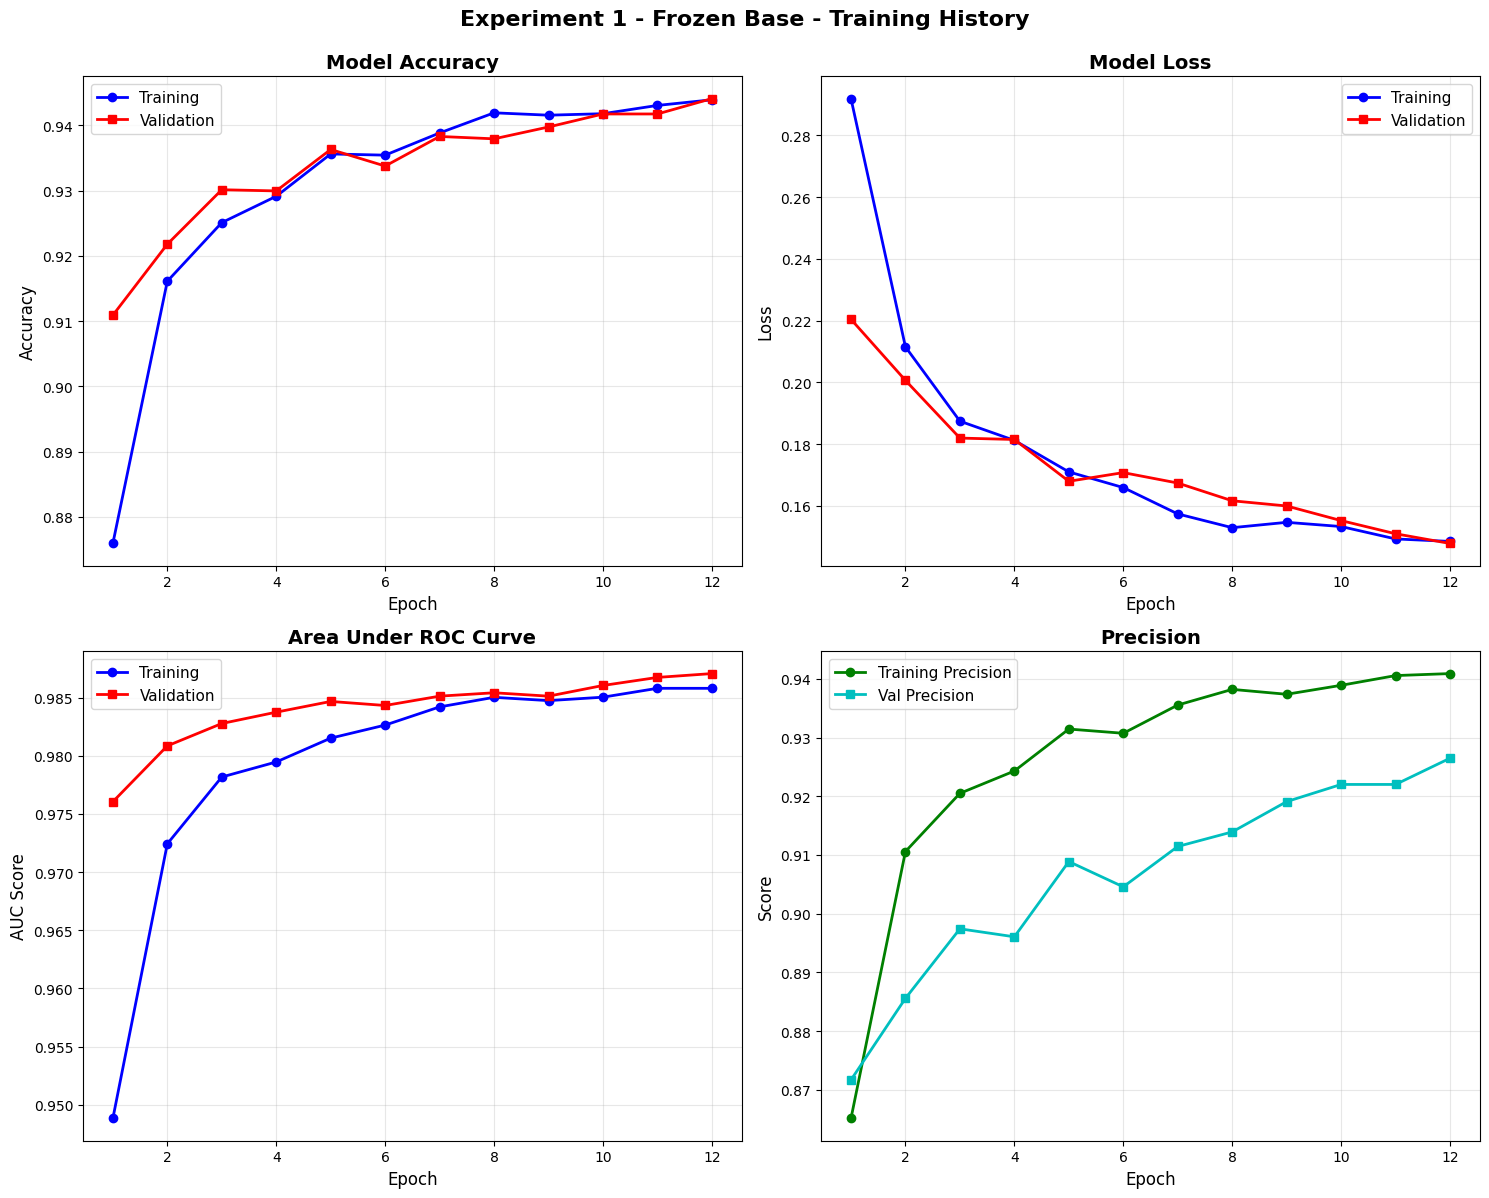

✓ Confusion matrix saved to reports/exp1/confusion_matrix.png


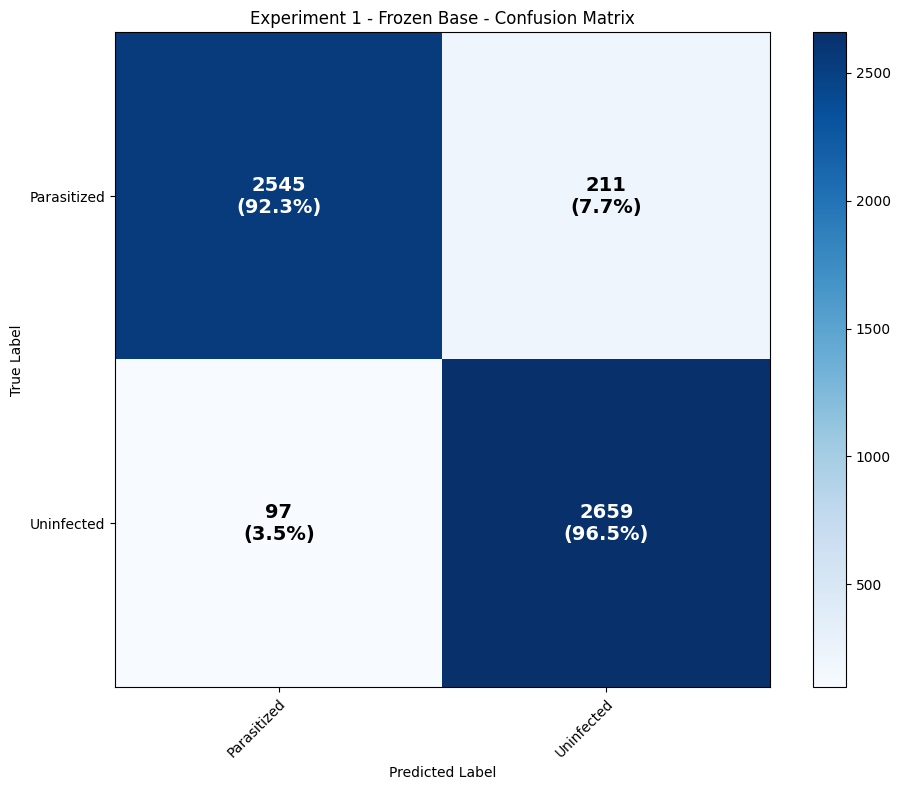


Confusion Matrix Statistics:
  True Negatives:  2545
  False Positives: 211
  False Negatives: 97
  True Positives:  2659
✓ ROC curve saved to reports/exp1/roc_curve.png


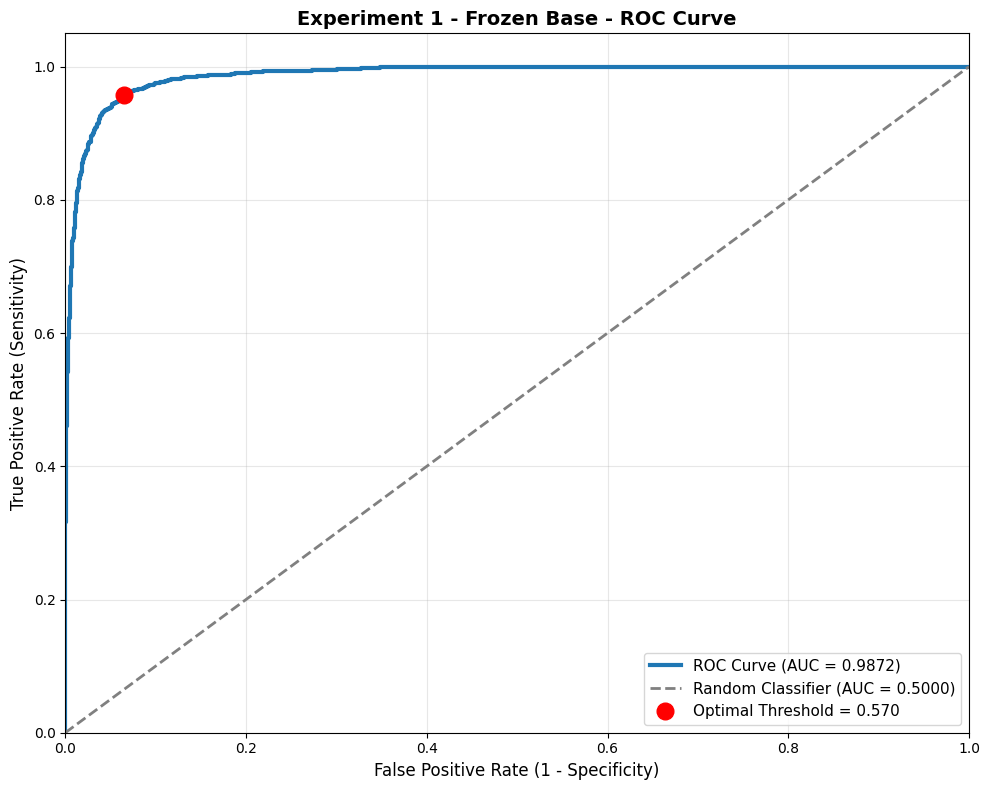


ROC Curve Analysis:
  AUC Score: 0.9872
  Optimal Threshold: 0.570
  Sensitivity at optimal: 0.9572
  Specificity at optimal: 0.9351
✓ Precision-Recall curve saved to reports/exp1/pr_curve.png


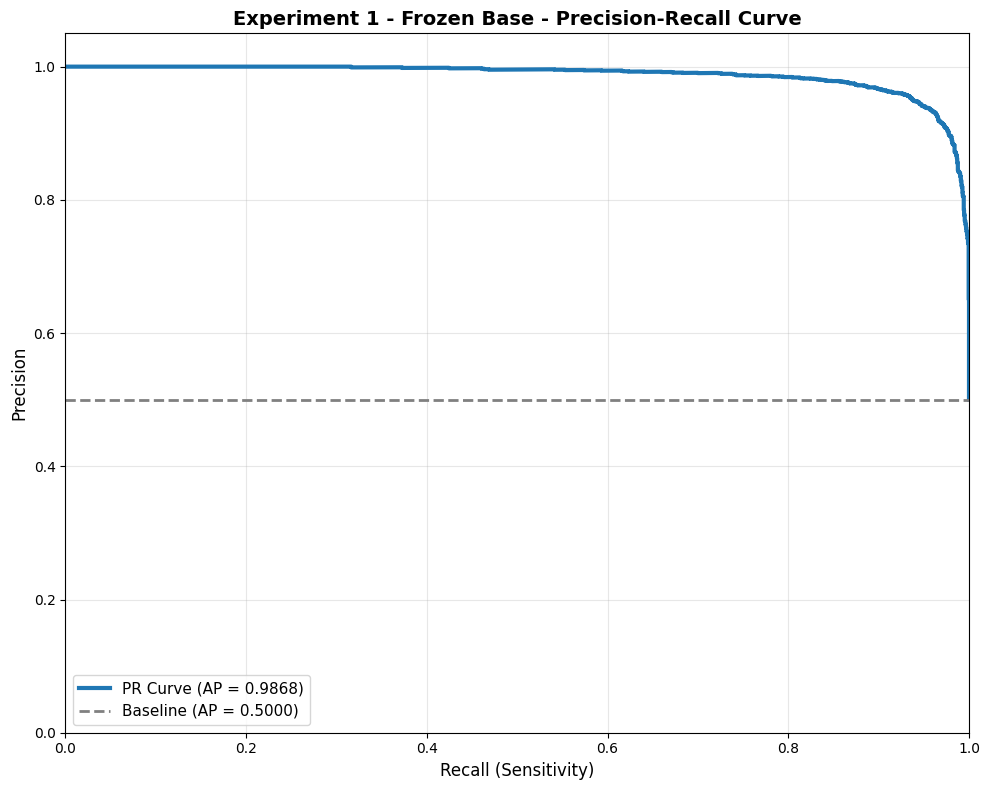


Precision-Recall Analysis:
  Average Precision: 0.9868

REPORT GENERATION COMPLETE


📋 STEP 5: Experiment 2 - Fine-tuned Model
----------------------------------------------------------------------

🔬 EXPERIMENT 2: FINE-TUNED MODEL
Strategy: Unfreeze top 30 layers and fine-tune with
          a lower learning rate for better feature adaptation.


FINE-TUNING CONFIGURATION
Frozen layers:   154
Unfrozen layers: 21
Total layers:    175


MODEL ARCHITECTURE SUMMARY
Total parameters:     24,121,729
Trainable parameters: 14,958,081
Frozen parameters:    9,163,648
Base model layers:    175

✓ Model compiled with learning rate: 1e-05

STARTING TRAINING - 12 EPOCHS

Epoch 1/12
345/345 ━━━━━━━━━━━━━━━━━━━━ 155s 416ms/step - accuracy: 0.9496 - auc: 0.9873 - loss: 0.1399 - precision: 0.9444 - recall: 0.9543 - val_accuracy: 0.9530 - val_auc: 0.9901 - val_loss: 0.1257 - val_precision: 0.9558 - val_recall: 0.9499 - learning_rate: 1.0000e-05
Epoch 2/12
345/345 ━━━━━━━━━━━━━━━━━━━━ 198s 407ms/step - a

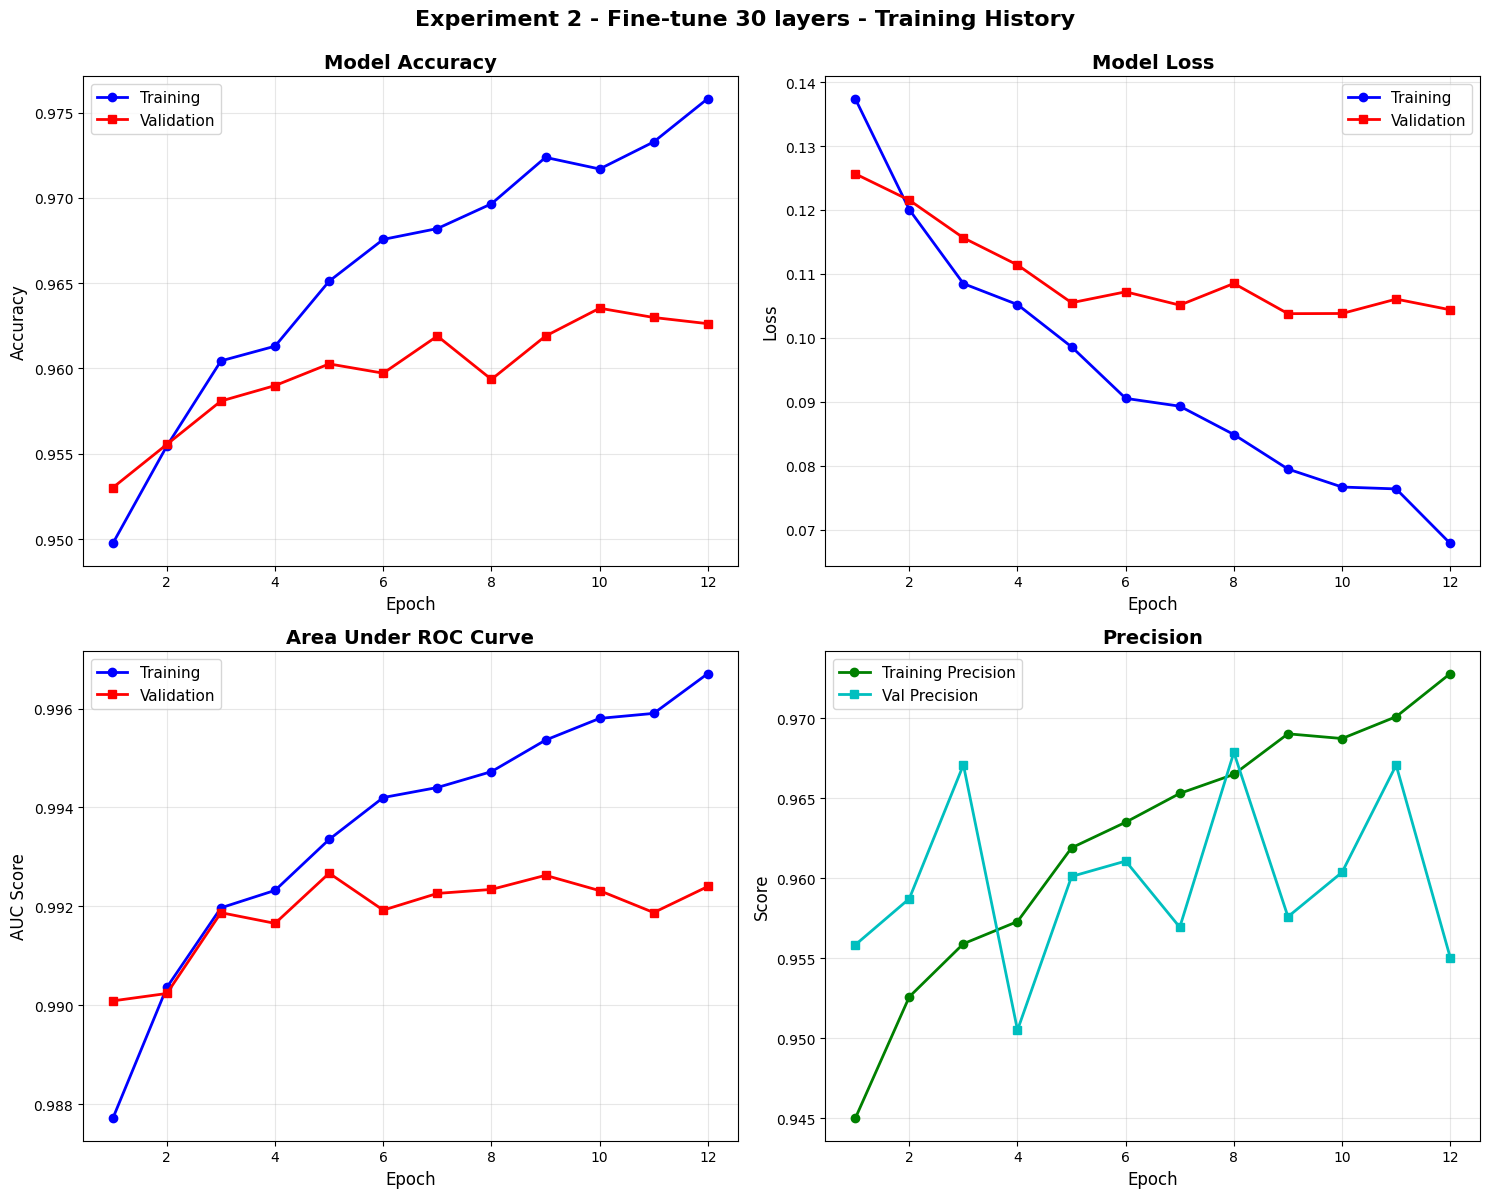

✓ Confusion matrix saved to reports/exp2/confusion_matrix.png


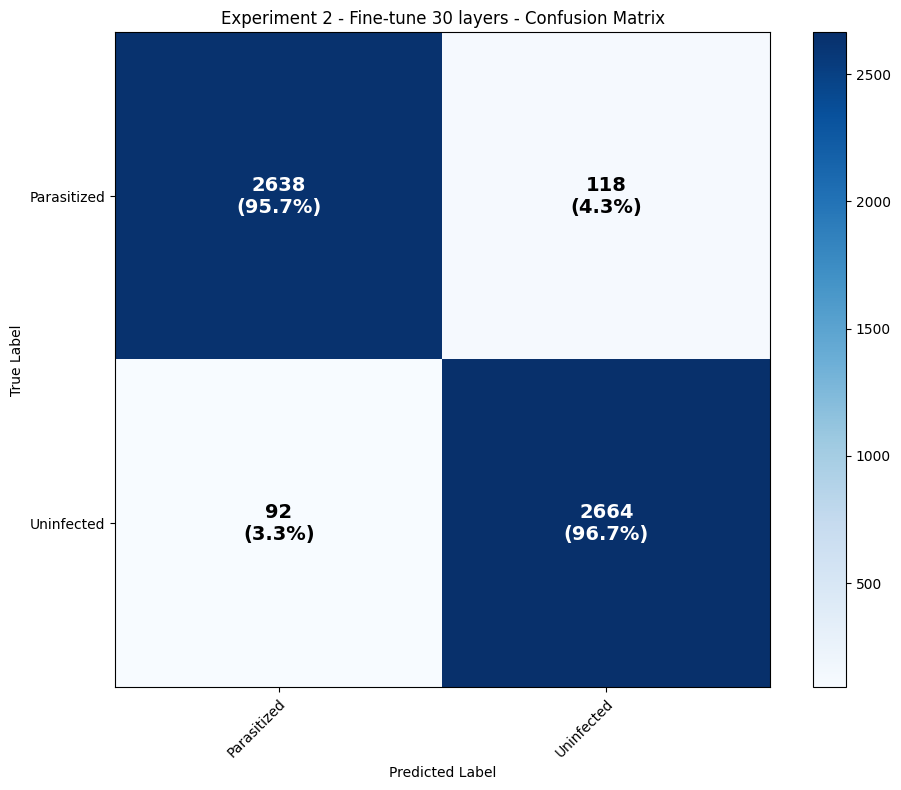


Confusion Matrix Statistics:
  True Negatives:  2638
  False Positives: 118
  False Negatives: 92
  True Positives:  2664
✓ ROC curve saved to reports/exp2/roc_curve.png


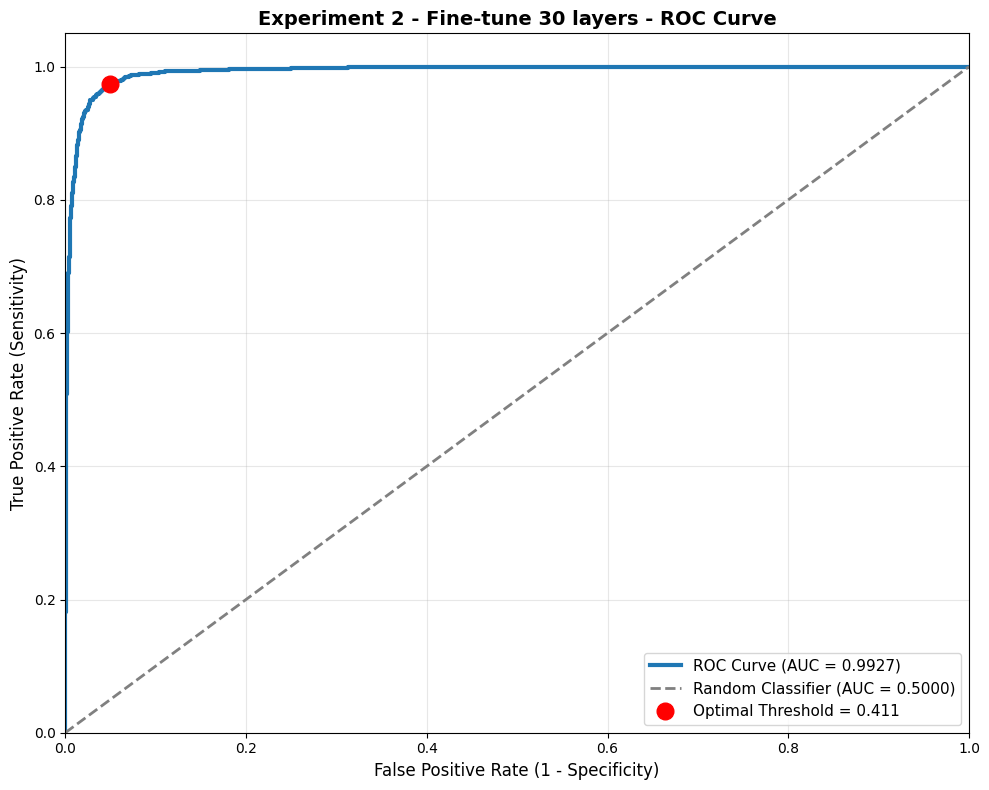


ROC Curve Analysis:
  AUC Score: 0.9927
  Optimal Threshold: 0.411
  Sensitivity at optimal: 0.9742
  Specificity at optimal: 0.9510
✓ Precision-Recall curve saved to reports/exp2/pr_curve.png


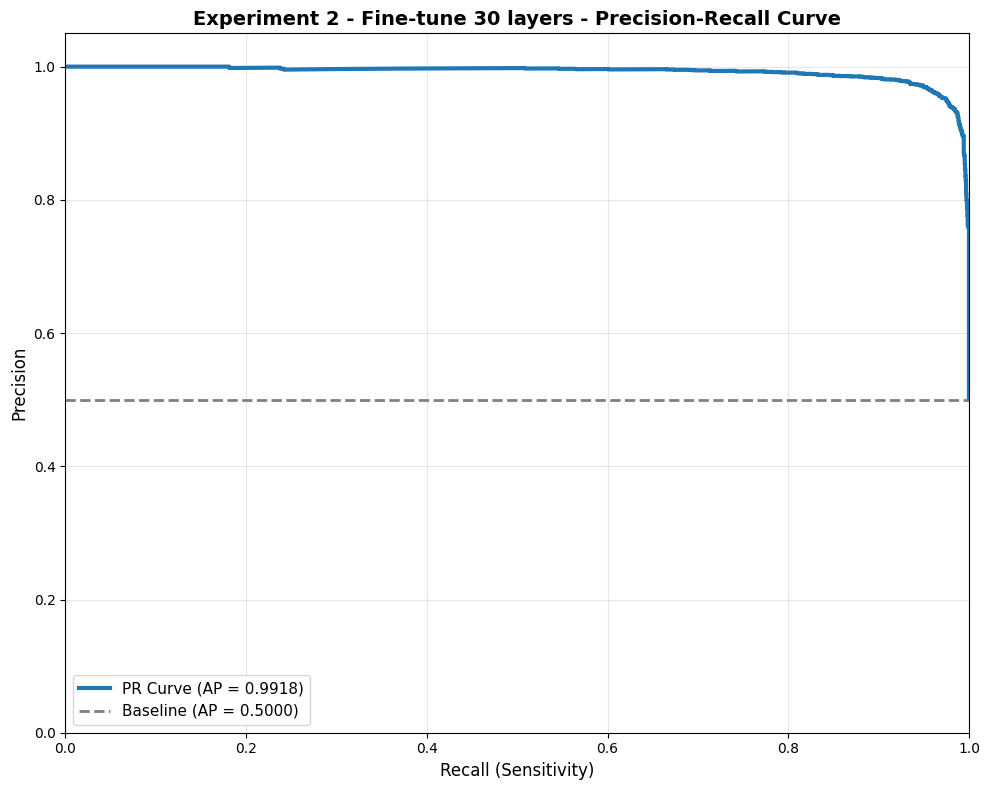


Precision-Recall Analysis:
  Average Precision: 0.9918

REPORT GENERATION COMPLETE


📋 STEP 6: Final Comparison
----------------------------------------------------------------------

EXPERIMENT COMPARISON
     Experiment  accuracy  precision   recall       f1      auc  specificity
E1: Frozen Base  0.944122   0.926481 0.964804 0.945254 0.987245     0.923440
 E2: Fine-tuned  0.961901   0.957584 0.966618 0.962080 0.992698     0.957184


📊 Generating comparison visualizations...
✓ Metric comparison saved to reports/metric_comparison.png


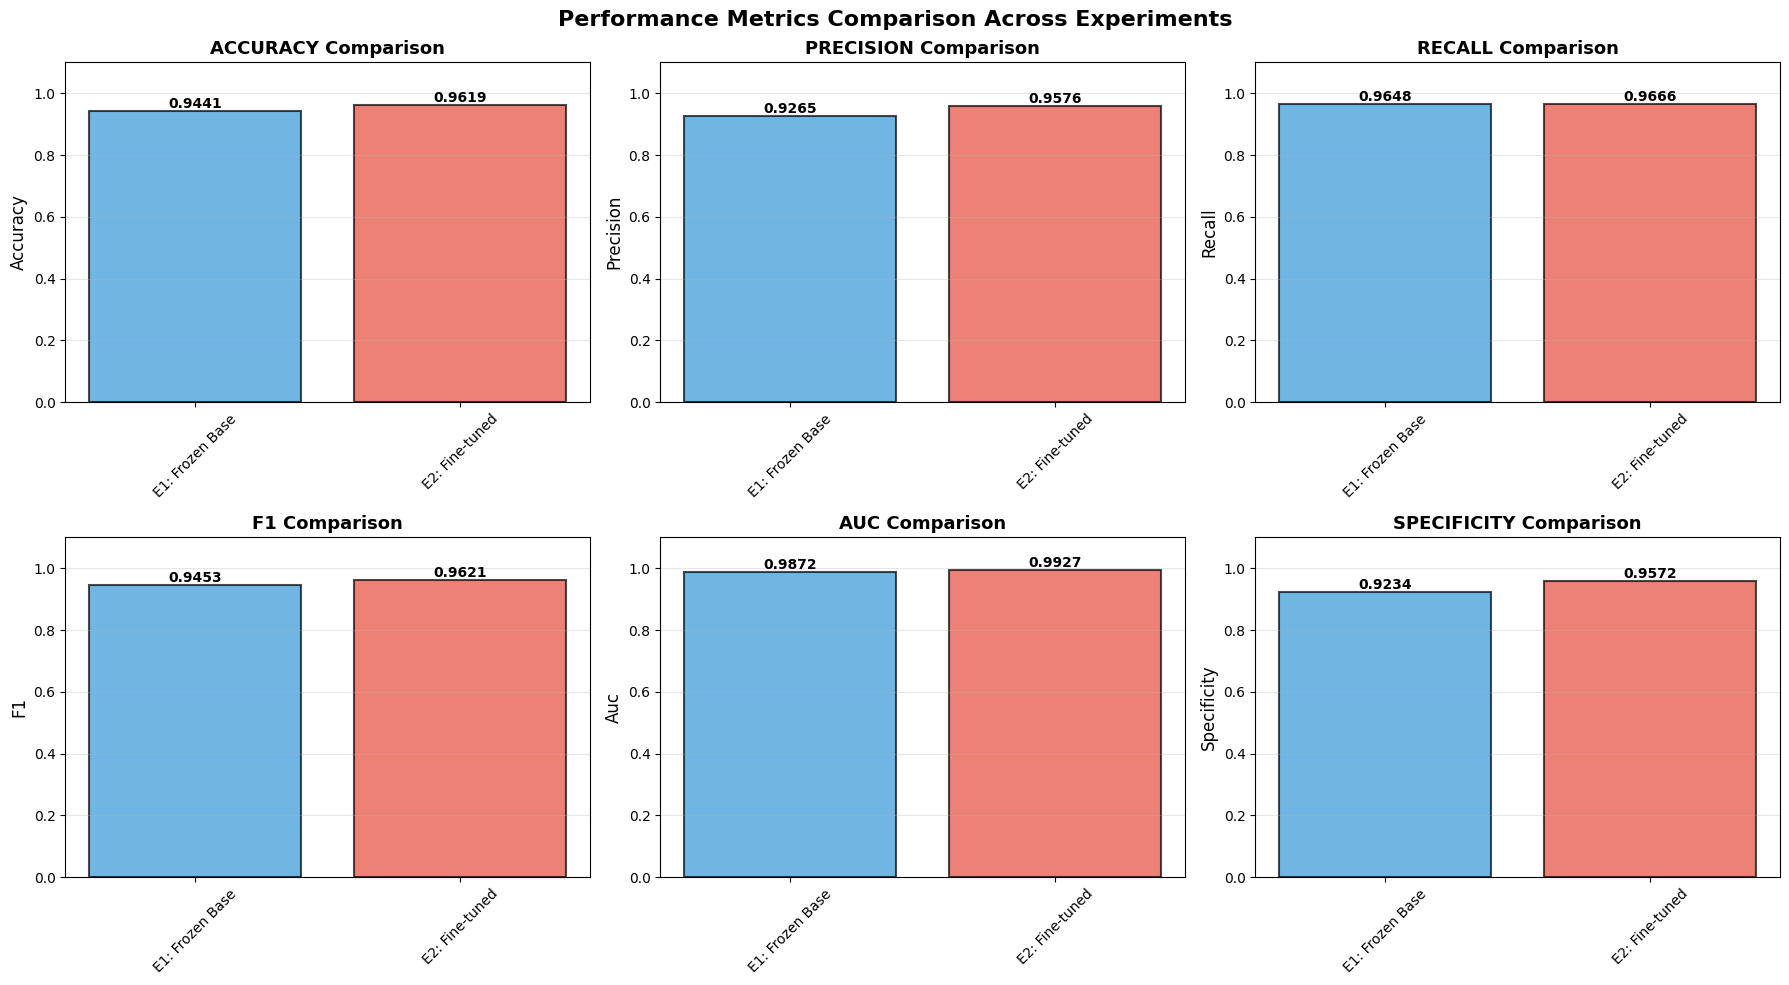

✓ ROC comparison saved to reports/roc_comparison.png


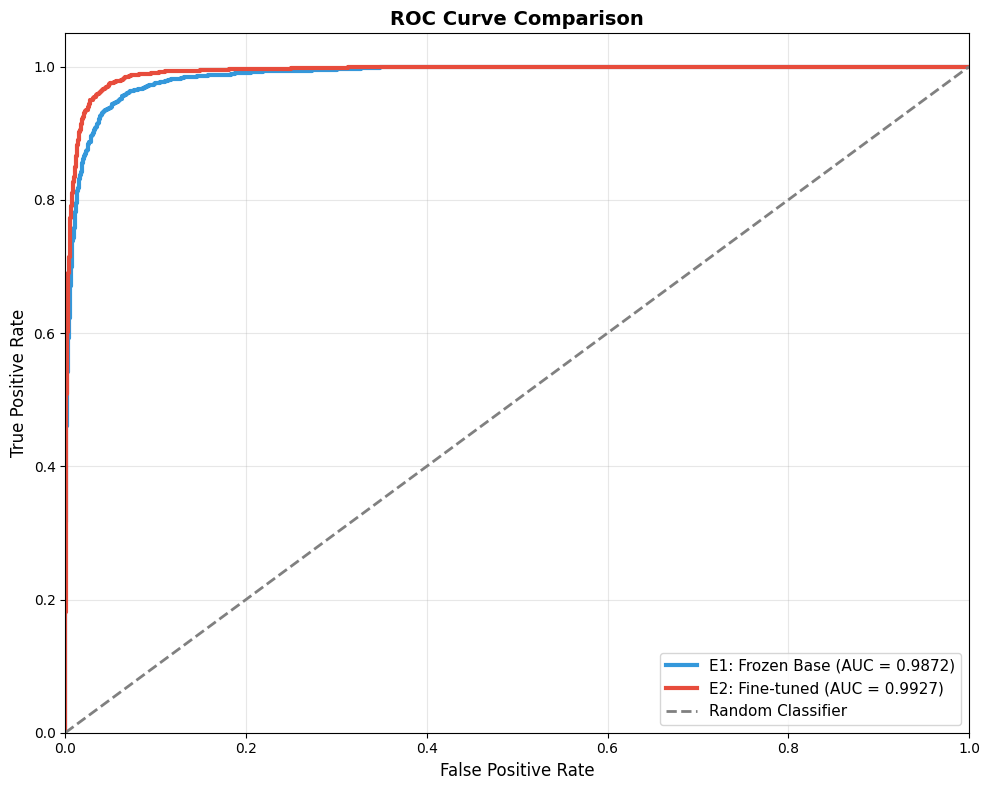


🎯 KEY FINDINGS
✓ Accuracy improvement: +1.88%
✓ F1-Score improvement: +1.78%
✓ Best model: E2 (Fine-tuned)

✅ PIPELINE COMPLETE - All experiments finished successfully!

🎉 All experiments completed successfully!

Results stored in 'results' dictionary with keys:
  - 'models': Trained models (e1, e2)
  - 'results': Evaluation results (e1, e2)
  - 'histories': Training histories (e1, e2)
  - 'comparison': Comparison DataFrame

✓ Comparison results saved to 'reports/experiment_comparison.csv'


In [13]:
# ============================================================================
# SECTION 10: EXECUTION
# ============================================================================

if __name__ == "__main__":
    """
    Execute the complete pipeline.

    Note: Set download_data=False if data is already downloaded.
    """

    # Run the complete pipeline
    results = main_pipeline(
        download_data=True,  # Set to False if data already exists
        train_ratio=0.8      # 80% training, 20% testing
    )

    print("\n🎉 All experiments completed successfully!")
    print("\nResults stored in 'results' dictionary with keys:")
    print("  - 'models': Trained models (e1, e2)")
    print("  - 'results': Evaluation results (e1, e2)")
    print("  - 'histories': Training histories (e1, e2)")
    print("  - 'comparison': Comparison DataFrame")

    # Save comparison results
    results['comparison'].to_csv('reports/experiment_comparison.csv', index=False)
    print("\n✓ Comparison results saved to 'reports/experiment_comparison.csv'")


In [14]:
# ============================================================================
# ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def save_model(model, filepath, include_optimizer=True):
    """
    Save trained model to disk.

    Args:
        model: Keras model to save
        filepath: Path to save the model
        include_optimizer: Whether to save optimizer state
    """
    model.save(filepath, include_optimizer=include_optimizer)
    print(f"✓ Model saved to {filepath}")


def load_saved_model(filepath):
    """
    Load a saved model from disk.

    Args:
        filepath: Path to the saved model

    Returns:
        Loaded Keras model
    """
    model = tf.keras.models.load_model(filepath)
    print(f"✓ Model loaded from {filepath}")
    return model


def predict_single_image(model, image_path, class_names):
    """
    Make prediction on a single image.

    Args:
        model: Trained model
        image_path: Path to image file
        class_names: List of class names

    Returns:
        Dictionary with prediction results
    """
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(
        image_path, target_size=DataConfig.IMG_SIZE
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = preprocess_for_resnet(img_array)
    img_array = tf.expand_dims(img_array, 0)

    # Predict
    prob = model.predict(img_array, verbose=0)[0][0]
    pred_class = int(prob >= 0.5)

    result = {
        'predicted_class': class_names[pred_class],
        'probability': prob,
        'confidence': prob if pred_class == 1 else 1 - prob
    }

    return result


In [15]:
# ============================================================================
# END OF MODULE
# ============================================================================

print("\n" + "="*70)
print("📚 Malaria Detection Module Loaded Successfully")
print("="*70)
print("\nAvailable functions:")
print("  • main_pipeline() - Run complete experiment pipeline")
print("  • run_experiment_1() - Run frozen base experiment")
print("  • run_experiment_2() - Run fine-tuning experiment")
print("  • evaluate_model() - Evaluate a trained model")
print("  • plot_training_history() - Visualize training curves")
print("  • plot_confusion_matrix() - Display confusion matrix")
print("  • plot_roc_curve() - Plot ROC curve")
print("  • compare_experiments() - Compare multiple experiments")
print("  • predict_single_image() - Make single prediction")
print("="*70 + "\n")


📚 Malaria Detection Module Loaded Successfully

Available functions:
  • main_pipeline() - Run complete experiment pipeline
  • run_experiment_1() - Run frozen base experiment
  • run_experiment_2() - Run fine-tuning experiment
  • evaluate_model() - Evaluate a trained model
  • plot_training_history() - Visualize training curves
  • plot_confusion_matrix() - Display confusion matrix
  • plot_roc_curve() - Plot ROC curve
  • compare_experiments() - Compare multiple experiments
  • predict_single_image() - Make single prediction

